# KernelGap Synthetic Dataset v2

OPTION 3

In [8]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import KernelGap_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.training_candidate import train_candidate_optuna_angles
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

from src.kernel.metrics import geometric_difference

In [2]:
# ── 1. Data ────────────────────────────────────────────────────────────────
X, y = KernelGap_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

RESULTS_DIR = 'Results/KernelGap Synthetic v2'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

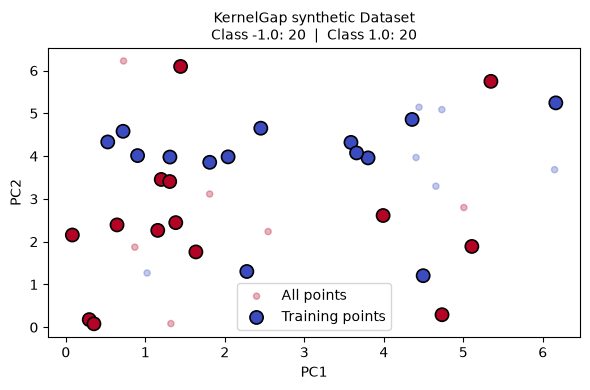

In [3]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('KernelGap synthetic', X, y, X_train, y_train, 'yes')

In [4]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric', 'haar', 'angles'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    ExperimentConfig(
        name='optuna kta',
        optimizer='optuna',
        variant='kta',
        subset_method='none',
        optimizer_kwargs={'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name='mealpy kta',
        optimizer='mealpy',
        variant='kta',
        subset_method='none',
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

In [5]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-08-21 09:08:38,186] A new study created in memory with name: no-name-029dfd51-bc2d-4d8a-8f80-8202f0adecbf



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna kta  [optuna + none]
────────────────────────────────────────────────────────────


[I 2026-08-21 09:08:40,548] Trial 0 finished with value: 0.15976606996560708 and parameters: {'gate_0': 'CNOT', 'angle_0': 0.6224293870908763, 'gate_1': 'H', 'angle_1': 2.808910917609123, 'gate_2': 'RY', 'angle_2': 0.7512147812452675, 'gate_3': 'RY', 'angle_3': 4.215444431557954, 'gate_4': 'I', 'angle_4': 5.54958875103929, 'gate_5': 'I', 'angle_5': 2.164302289110172, 'gate_6': 'RX', 'angle_6': 1.1937784653232597, 'gate_7': 'RY', 'angle_7': 2.985856417553512, 'gate_8': 'RX', 'angle_8': 3.1233992541531714, 'gate_9': 'I', 'angle_9': 1.8882382236729973, 'gate_10': 'RY', 'angle_10': 5.033606339849402, 'gate_11': 'RZ', 'angle_11': 6.2754540648464125, 'gate_12': 'I', 'angle_12': 1.9840035742528164, 'gate_13': 'I', 'angle_13': 2.40674493068847, 'gate_14': 'RX', 'angle_14': 1.8104704622541286, 'gate_15': 'CNOT', 'angle_15': 5.285854876445465}. Best is trial 0 with value: 0.15976606996560708.
[I 2026-08-21 09:08:43,191] Trial 1 finished with value: 0.16318487475663407 and parameters: {'gate_0': 

Saved candidate  → Results/KernelGap Synthetic v2/optuna kta/candidate.pkl
Computing cross-kernel (test × subset)…


2026/08/21 09:12:05 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=30, pop_size=20, pc=0.95, pm=0.1)


Saved SVM        → Results/KernelGap Synthetic v2/optuna kta/svm.pkl

REPORT: optuna kta | 100 trials
Best C            : 10
Best CV accuracy  : 0.9667
Test accuracy     : 0.9167
              precision    recall  f1-score   support

        -1.0       1.00      0.83      0.91         6
         1.0       0.86      1.00      0.92         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12


────────────────────────────────────────────────────────────
 mealpy kta  [mealpy + none]
────────────────────────────────────────────────────────────


2026/08/21 09:13:23 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 0.408399807671288, Global best: 0.5087797547329994, Runtime: 40.98320 seconds
2026/08/21 09:13:58 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 0.4856616515538152, Global best: 0.5087797547329994, Runtime: 35.60245 seconds
2026/08/21 09:14:35 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 0.5257666738392803, Global best: 0.5257666738392803, Runtime: 36.72024 seconds
2026/08/21 09:15:09 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 0.4523648997472988, Global best: 0.5257666738392803, Runtime: 34.14431 seconds
2026/08/21 09:15:46 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 0.4451279437276833, Global best: 0.5257666738392803, Runtime: 37.24671 seconds
2026/08/21 09:16:25 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Proble

Saved candidate  → Results/KernelGap Synthetic v2/mealpy kta/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/KernelGap Synthetic v2/mealpy kta/svm.pkl

REPORT: mealpy kta | 30 epochs | 20 pop | 0.1 pm
Best C            : 0.1
Best CV accuracy  : 1.0000
Test accuracy     : 1.0000
              precision    recall  f1-score   support

        -1.0       1.00      1.00      1.00         6
         1.0       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [9]:
data = load_parameter_train('optuna kta')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference optuna kta = {g:.4f}")

data = load_parameter_train('mealpy kta')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference mealpy kta = {g:.4f}")

Geometric difference optuna kta = 11.0535
Geometric difference mealpy kta = 3.2988


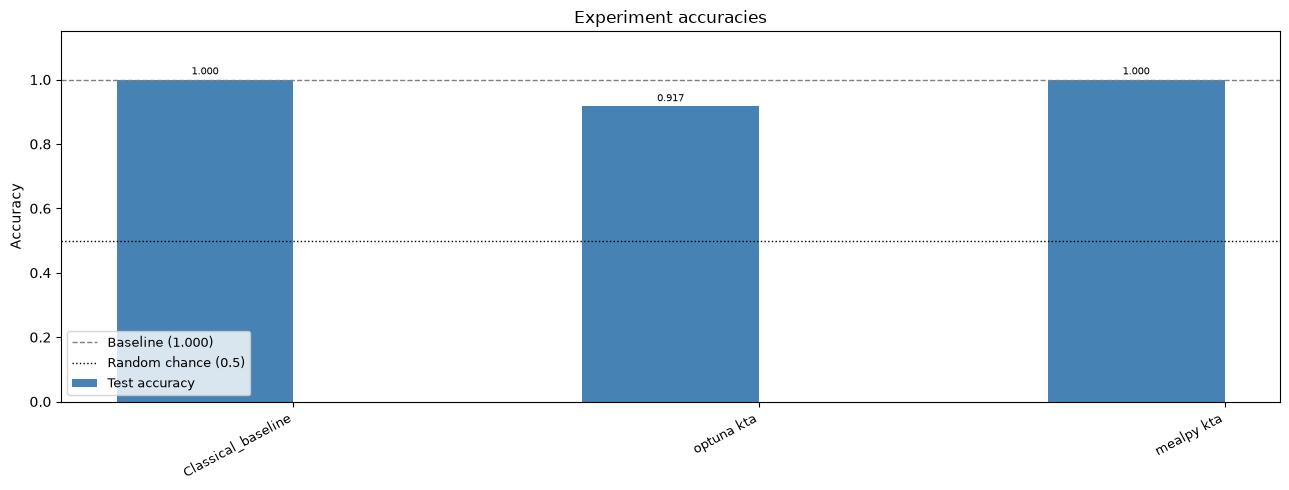

Saved → Results/KernelGap Synthetic v2/accuracy_comparison.png


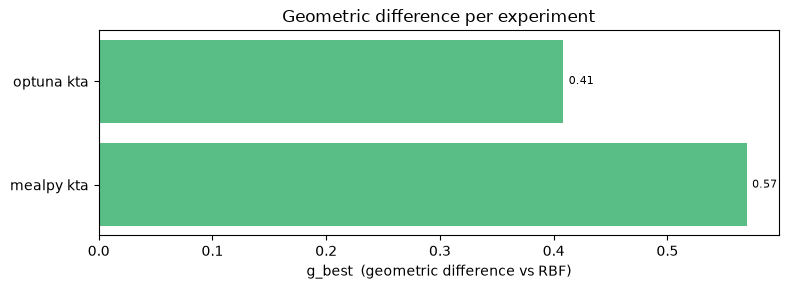

Saved → Results/KernelGap Synthetic v2/g_best_comparison.png


In [10]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────

plot_accuracy(summary, ['test'])
plot_g_best(summary)

In [12]:
data = load_parameter_train('optuna kta')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference optuna kta = {g:.4f}")

data = load_parameter_train('mealpy kta')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference mealpy kta = {g:.4f}")

Geometric difference optuna kta = 11.0535
Geometric difference mealpy kta = 3.2988


In [15]:
data = load_parameter_train(config.name)   # or config.load_from or config.name
candidate = data['candidate']

gates  = [gene.gate  for gene in candidate.genes]
angles = [gene.angle for gene in candidate.genes]

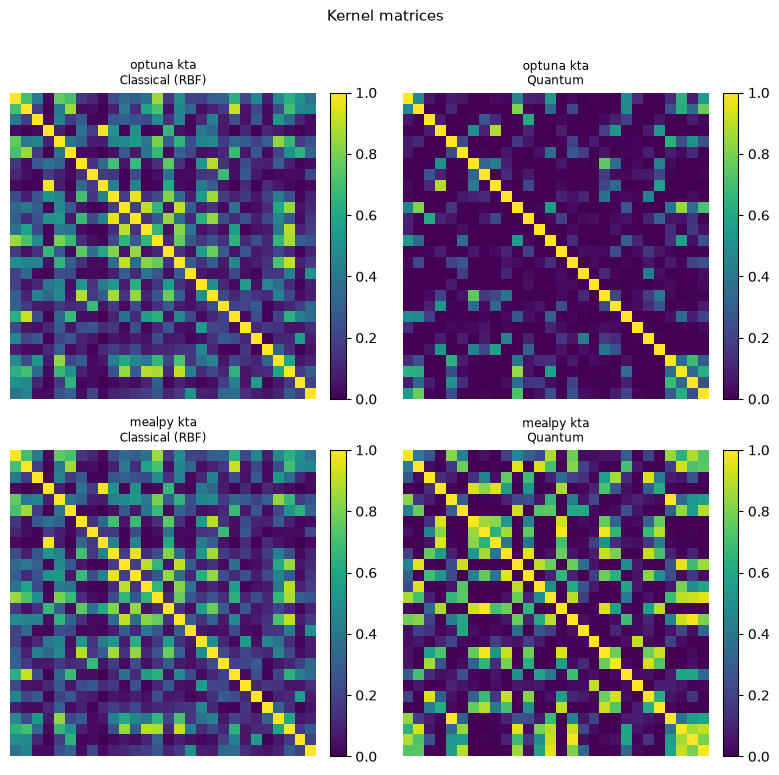

Saved → Results/KernelGap Synthetic v2/kernel_heatmaps.png


In [11]:
plot_kernel_heatmaps(summary)